[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/agent-memory.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239417-lesson-7-agent-with-memory)

# Agent memory

## Review

Previously, we built an agent that can:

* `act` - let the model call specific tools 
* `observe` - pass the tool output back to the model 
* `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

![Screenshot 2024-08-21 at 12.45.32 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab7453080e6802cd1703_agent-memory1.png)

## Goals

Now, we're going extend our agent by introducing memory.

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langgraph-prebuilt

In [9]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

#_set_env("OPENAI_API_KEY")
_set_env("GEMINI_API_KEY")

GEMINI_API_KEY:  ········


In [13]:
GEMINI_API_KEY

''

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

In [14]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

This follows what we did previously.

In [16]:
#from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)
llm_with_tools = llm.bind_tools(tools)

In [17]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [46]:
inputs = {"messages": [HumanMessage(content="What is 15 multiplied by 4?")]}
output=assistant(inputs)

In [49]:
output['messages']

[AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 4, "a": 15}'}, '__gemini_function_call_thought_signatures__': {'c5cc6a8c-7526-4dda-acfa-d4b76aa779cd': 'CvoBAQw51sdemP2mVlSnB6A6ZxhNIq2cEPlgYrWE+TK6ioKG+im/jqIMsITmdwzVzbfkbwkuujz/QYZZkF1wLaqHrVp4SfcJ98gofnH0BXAB5I8vjo1LfM75d7s0blLK3R+8v7coZLZOQZ89D87VWWGvXlOLoszHx+vOmNyzMCOlO2PqaZiVVVqvDkmeW5+ZyssLXFmG045MGqETX2aX2I4xSvSMzyWEO0cOyk9HNAuO0OjpKG1NAH0qbGudZRRJKdZhiKHvl4NPLLIwZVFQuh/9uv2YYJGnLXXgGrsIZHileDQHey1ugMPHP4+MAnlFeFL4xwqzajGvmYjmag=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dd794-6c67-7073-9028-75e695c1f019-0', tool_calls=[{'name': 'multiply', 'args': {'b': 4, 'a': 15}, 'id': 'c5cc6a8c-7526-4dda-acfa-d4b76aa779cd', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 84, 'total_tokens': 254, 'input_token_details': {'cache_r

In [45]:
import langchain
langchain.debug = True
langchain.verbose = True

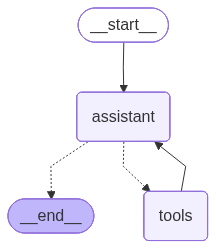

In [18]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

## Memory

Let's run our agent, as before.

In [19]:
messages = [HumanMessage(content="Add 3 and 4.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (e6be50e9-7824-4a41-9c58-cb4fb0e2b4b2)
 Call ID: e6be50e9-7824-4a41-9c58-cb4fb0e2b4b2
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [24]:
messages['messages'][1]

AIMessage(content='', additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"a": 3, "b": 4}'}, '__gemini_function_call_thought_signatures__': {'e6be50e9-7824-4a41-9c58-cb4fb0e2b4b2': 'CvIBAQw51sc/k386dPKPWBt3AYUDgW0KLOOvt52BdqaRFvLWHr3DOYVuFTrW4a3qBBn1SSXKREjU4YLBrsOj3j2A41Aoa5YWciwfA+Bj0C7PDElisB1URtmWKie3wEgbS5v3u5hGaUX6e6GxBdHtsdm9ikfSmFdyeBHn8PfEIvCC1cNErau6nd6qyAr/9QVY98neOpthFTvWETnz0j698sOZmqI8JeYPpbFmsrNUOGbgKlfk7oRY4kEE8j8kHrGErJ9LOBdZO5qSuEsclqTfR/l793ssux+euQwnix1gg+FNG63S/ZS/ByiMqoVUAQIlPCE7iY0='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dd75b-924f-7352-9f2a-45d084fbcf54-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'e6be50e9-7824-4a41-9c58-cb4fb0e2b4b2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 167, 'output_tokens': 79, 'total_tokens': 246, 'input_token_details': {'cache_read': 0}, 'output_token_d

Now, let's multiply by 2!

In [7]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (call_prnkuG7OYQtbrtVQmH2d3Nl7)
 Call ID: call_prnkuG7OYQtbrtVQmH2d3Nl7
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4
================================== Ai Message ==================================

The result of multiplying 2 by 2 is 4.


We don't retain memory of 7 from our initial chat!

This is because [state is transient](https://github.com/langchain-ai/langgraph/discussions/352#discussioncomment-9291220) to a single graph execution.

Of course, this limits our ability to have multi-turn conversations with interruptions. 

We can use [persistence](https://docs.langchain.com/oss/python/langgraph/persistence) to address this! 

LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update. 

One of the easiest checkpointers to use is the `MemorySaver`, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

In [50]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

When we use memory, we need to specify a `thread_id`.

This `thread_id` will store our collection of graph states.

Here is a cartoon:

* The checkpointer write the state at every step of the graph
* These checkpoints are saved in a thread 
* We can access that thread in the future using the `thread_id`

![state.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e0e9f526b41a4ed9e2d28b_agent-memory2.png)


In [56]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content="Add 3 and 4.")]

# Run
messages = react_graph_memory.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (a11bf9ba-c736-4f87-b933-79d309890cd6)
 Call ID: a11bf9ba-c736-4f87-b933-79d309890cd6
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (d66d3144-55b2-4dbc-ad94-06d003ceb135)
 Call ID: d66d3144-55b2-4dbc-ad94-06d003ceb135
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message =============================

If we pass the same `thread_id`, then we can proceed from from the previously logged state checkpoint! 

In this case, the above conversation is captured in the thread.

The `HumanMessage` we pass (`"Multiply that by 2."`) is appended to the above conversation.

So, the model now know that `that` refers to the `The sum of 3 and 4 is 7.`.

In [57]:
state = react_graph_memory.get_state(config)

In [58]:
for msg in state.values["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (a11bf9ba-c736-4f87-b933-79d309890cd6)
 Call ID: a11bf9ba-c736-4f87-b933-79d309890cd6
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (d66d3144-55b2-4dbc-ad94-06d003ceb135)
 Call ID: d66d3144-55b2-4dbc-ad94-06d003ceb135
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message =============================

In [55]:
print(f"Next node to run: {state.next}")

Next node to run: ()


In [52]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (a11bf9ba-c736-4f87-b933-79d309890cd6)
 Call ID: a11bf9ba-c736-4f87-b933-79d309890cd6
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (d66d3144-55b2-4dbc-ad94-06d003ceb135)
 Call ID: d66d3144-55b2-4dbc-ad94-06d003ceb135
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message =============================

## Studio

**⚠️ Notice**

Since filming these videos, we've updated Studio so that it can now be run locally and accessed through your browser. This is the preferred way to run Studio instead of using the Desktop App shown in the video. It is now called _LangSmith Studio_ instead of _LangGraph Studio_. Detailed setup instructions are available in the "Getting Setup" guide at the start of the course. You can find a description of Studio [here](https://docs.langchain.com/langsmith/studio), and specific details for local deployment [here](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server).  
To start the local development server, run the following command in your terminal in the `/studio` directory in this module:

```
langgraph dev
```

You should see the following output:
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

Open your browser and navigate to the **Studio UI** URL shown above.
Load the `agent` in Studio, which uses `module-1/studio/agent.py` set in `module-1/studio/langgraph.json`.